In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
pd.set_option("display.max_columns", None)

In [2]:
import os
print(os.getcwd())

C:\Users\tmadh\Downloads


In [3]:
import os
for f in os.listdir():
    print(f, "->", os.path.isdir(f))

.ipynb_checkpoints -> True
all -> True
desktop.ini -> False
superstore.csv -> False
superstore_finaldataset.csv -> True
superstore_final_dataset (1).csv.zip -> False
Super_Store.ipynb -> False


In [4]:
import os
print(os.path.getsize("superstore.csv"))

2124717


In [5]:
import pandas as pd
df = pd.read_csv("superstore.csv", encoding='latin1')
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (9800, 18)

Columns:
['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category', 'Product_Name', 'Sales']


In [6]:
with open("superstore.csv", "rb") as f:
    print(f.read(100))

b'Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,'


In [7]:
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.replace("\xa0", " ", regex=False).str.strip()

C:\Users\tmadh\AppData\Local\Temp\ipykernel_4712\3444849943.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [8]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce", dayfirst=True)
df["Ship_Date"] = pd.to_datetime(df["Ship_Date"], errors="coerce", dayfirst=True)
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")
df = df.drop_duplicates().copy()
df["Ship_Delay_Days"] = (df["Ship_Date"] - df["Order_Date"]).dt.days
df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.month
df["Month_Name"] = df["Order_Date"].dt.strftime("%b")
df["Quarter"] = df["Order_Date"].dt.quarter
df["Day_of_Week"] = df["Order_Date"].dt.day_name()

In [9]:
kpis = pd.DataFrame([
    ["Total Rows", len(df)],
    ["Total Sales", df["Sales"].sum()],
    ["Average Sales", df["Sales"].mean()],
    ["Median Sales", df["Sales"].median()],
    ["Total Orders", df["Order_ID"].nunique()],
    ["Total Customers", df["Customer_ID"].nunique()],
    ["Total Products", df["Product_ID"].nunique()],
    ["Average Ship Delay (days)", df["Ship_Delay_Days"].mean()],
], columns=["Metric", "Value"])
kpis

,Metric,Value
0,Total Rows,9.800000e+03
1,Total Sales,2.261537e+06
2,Average Sales,2.307691e+02
3,Median Sales,5.449000e+01
4,Total Orders,4.922000e+03
5,Total Customers,7.930000e+02
6,Total Products,1.861000e+03
7,Average Ship Delay (days),3.961122e+00


In [10]:
region_perf = (
    df.groupby("Region")
      .agg(
          Total_Sales=("Sales", "sum"),
          Avg_Sales=("Sales", "mean"),
          Total_Orders=("Order_ID", "nunique")
      )
      .reset_index()
      .sort_values("Total_Sales", ascending=False)
)
region_perf

,Region,Total_Sales,Avg_Sales,Total_Orders
3,West,710219.6845,226.184613,1587
1,East,669518.7260,240.401697,1369
0,Central,492646.9132,216.357889,1156
2,South,389151.4590,243.524067,810


In [11]:
category_perf = (
    df.groupby("Category")
      .agg(
          Total_Sales=("Sales", "sum"),
          Avg_Sales=("Sales", "mean"),
          Total_Orders=("Order_ID", "nunique")
      )
      .reset_index()
      .sort_values("Total_Sales", ascending=False)
)
category_perf

,Category,Total_Sales,Avg_Sales,Total_Orders
2,Technology,827455.8730,456.401474,1519
0,Furniture,728658.5757,350.653790,1727
1,Office Supplies,705422.3340,119.381001,3676


In [12]:
subcat_perf = (
    df.groupby("Sub_Category")
      .agg(
          Total_Sales=("Sales", "sum"),
          Avg_Sales=("Sales", "mean"),
          Total_Orders=("Order_ID", "nunique")
      )
      .reset_index()
      .sort_values("Total_Sales", ascending=False)
)
subcat_perf.head(10)

,Sub_Category,Total_Sales,Avg_Sales,Total_Orders
13,Phones,327782.4480,374.180877,803
5,Chairs,322822.7310,531.833165,566
14,Storage,219343.3920,263.633885,764
16,Tables,202810.6280,645.893720,302
3,Binders,200028.7850,134.067550,1291
11,Machines,189238.6310,1645.553313,112
0,Accessories,164186.7000,217.178175,702
6,Copiers,146248.0940,2215.880212,66
4,Bookcases,113813.1987,503.598224,222
1,Appliances,104618.4030,227.926804,444


In [13]:
top_cities = (
    df.groupby("City")
      .agg(Total_Sales=("Sales", "sum"))
      .reset_index()
      .sort_values("Total_Sales", ascending=False)
      .head(15)
)
top_products = (
    df.groupby("Product_Name")
      .agg(Total_Sales=("Sales", "sum"))
      .reset_index()
      .sort_values("Total_Sales", ascending=False)
      .head(15)
)
top_cities
top_products

,Product_Name,Total_Sales
403,Canon imageCLASS 2200 Advanced Copier,61599.8240
648,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.3840
443,Cisco TelePresence System EX90 Videoconferenci...,22638.4800
783,HON 5400 Series Task Chairs for Big and Tall,21870.5760
684,GBC DocuBind TL300 Electric Binding System,19823.4790
686,GBC Ibimaster 500 Manual ProClick Binding System,19024.5000
802,Hewlett Packard LaserJet 3310 Copier,18839.6860
784,HP Designjet T520 Inkjet Large Format Printer ...,18374.8950
681,GBC DocuBind P400 Electric Binding System,17965.0680
810,High Speed Automatic Electric Letter Opener,17030.3120


In [14]:
monthly_trend = (
    df.dropna(subset=["Order_Date"])
      .groupby(pd.Grouper(key="Order_Date", freq="ME"))
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Orders=("Order_ID", "nunique")
      )
      .reset_index()
)
monthly_trend

,Order_Date,Total_Sales,Total_Orders
0,2015-01-31,14205.7070,30
1,2015-02-28,4519.8920,28
2,2015-03-31,55205.7970,69
3,2015-04-30,27906.8550,63
4,2015-05-31,23644.3030,68
5,2015-06-30,34322.9356,64
6,2015-07-31,33781.5430,64
7,2015-08-31,27117.5365,70
8,2015-09-30,81623.5268,129
9,2015-10-31,31453.3930,78


In [15]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_trend = (
    df.groupby("Day_of_Week")
      .agg(Total_Sales=("Sales", "sum"))
      .reindex(weekday_order)
      .reset_index()
)
weekday_trend

,Day_of_Week,Total_Sales
0,Monday,348791.5516
1,Tuesday,420535.9243
2,Wednesday,315888.9722
3,Thursday,142839.2402
4,Friday,234710.8402
5,Saturday,420901.4763
6,Sunday,377868.7779


charts required

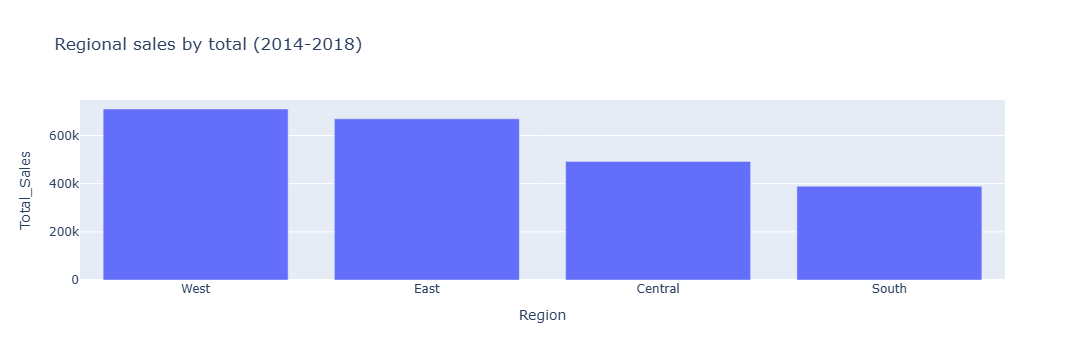

In [16]:
#regional sale
fig = px.bar(
    region_perf,
    x="Region",
    y="Total_Sales",
    title="Regional sales by total (2014-2018)"
)
fig.show()

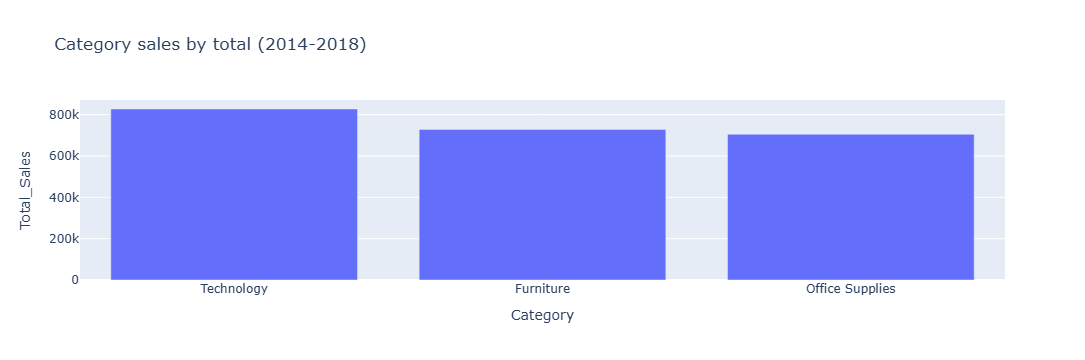

In [17]:
#category sale
fig = px.bar(
    category_perf,
    x="Category",
    y="Total_Sales",
    title="Category sales by total (2014-2018)"
)
fig.show()

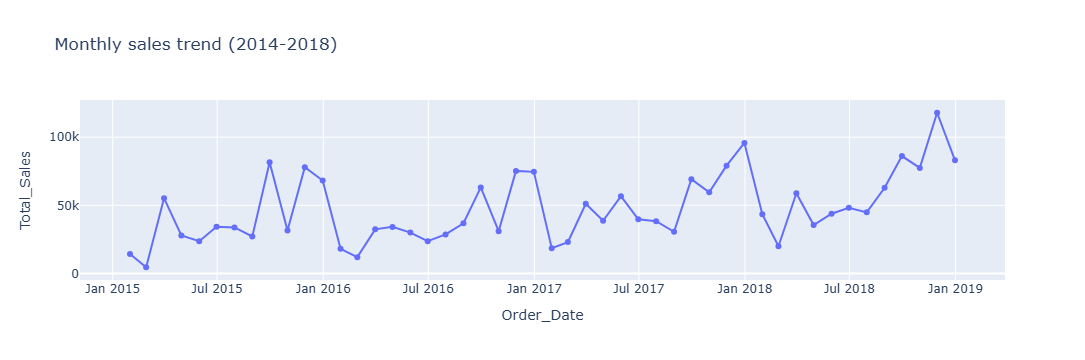

In [18]:
#monthly trend
fig = px.line(
    monthly_trend,
    x="Order_Date",
    y="Total_Sales",
    markers=True,
    title="Monthly sales trend (2014-2018)"
)
fig.show()

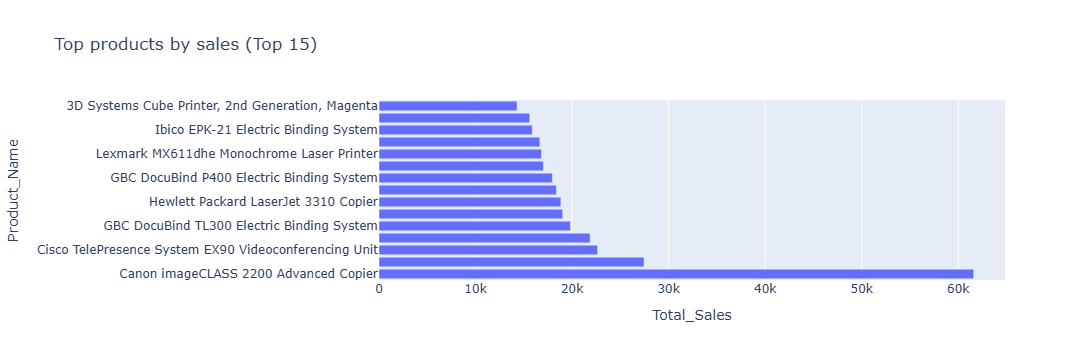

In [19]:
#top products
fig = px.bar(
    top_products,
    x="Total_Sales",
    y="Product_Name",
    orientation="h",
    title="Top products by sales (Top 15)"
)
fig.show()

3 Practical Suggestions
1. Promote Technology-Specific Campaigns
Technology provides the biggest chunk of revenues. More promotion, bundling, and marketing of technological products will bring in more money compared to allocating budget to all other items equally.
Anticipated Results: Increased average revenue per transaction and revenue growth.

2. Adopt Practices That Helped Western Region to Prosper
Western region performs the best in comparison to other regions. Study pricing, products offered, marketing efforts, and demographics of customers in the West. Adopt good practices for other two regions – Central and Southern.
Anticipated Results: Improved consistency of regional performance.

3. Utilize Peak Sales Time Effectively
Peak sales periods occur at certain times of year and on weekends. Create promotions, inventories, and advertising campaigns before these peak seasons.
Anticipated Results: Improved use of inventories and higher conversion rates.

Five Tactical Improvements
1. Product Bundling
Combine successful technology products with complimentary accessories in order to boost revenue per sale.

2. Sales Improvement in Underserving Regions
Offer region-specific sales promotions to underperforming regions (Central and South).

3. Customer Segmentation
Segment customers based on their RFM characteristics and launch personalized campaigns.

4. Campaign Timing by Region
Design a calendar of sales by season and ensure the timing of sales campaigns is optimized for maximum success.

5. Recommendation Engine
Leverage product recommendations in order to promote best-selling products, including Phones, Storage Devices, and Accessories.